In [1]:
import pandas as pd
#pd.set_option("display.max_columns", None)

In [2]:
# Load the data set
filtered_df = pd.read_csv("../data/filtered_icfes_data_cesar.csv")
filtered_df = filtered_df.map(lambda x: x.strip() if isinstance(x, str) else x)
filtered_df

,periodo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_mcpio_ubicacion,cole_jornada,cole_naturaleza,...,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224,URBANO,N,A,ACADÉMICO,120001006768,120001006768,20001,MAÑANA,OFICIAL,...,Si,No,Si,Si,42,49,48,45,47,234
1,20224,RURAL,N,A,ACADÉMICO,220001067435,220001067435,20001,UNICA,OFICIAL,...,Si,No,Si,Si,55,65,56,67,54,300
2,20224,RURAL,N,A,TÉCNICO/ACADÉMICO,220175017801,220175017801,20175,UNICA,OFICIAL,...,No,No,No,No,44,44,45,34,48,214
3,20224,URBANO,N,A,TÉCNICO,120001001201,120001001201,20001,TARDE,OFICIAL,...,No,Si,Si,Si,41,40,36,42,50,210
4,20224,URBANO,N,A,TÉCNICO/ACADÉMICO,120295000061,120295000061,20295,UNICA,OFICIAL,...,No,No,No,Si,31,40,30,33,44,182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63122,20162,URBANO,N,A,ACADÉMICO,120001000921,120001000921,20001,TARDE,OFICIAL,...,No,No,No,No,71,74,61,70,58,331
63123,20162,URBANO,N,A,TÉCNICO/ACADÉMICO,120400000111,120400000111,20400,TARDE,OFICIAL,...,No,No,No,Si,63,55,54,54,53,273
63124,20142,RURAL,N,A,ACADÉMICO,220013000395,220013000395,20013,MAÑANA,OFICIAL,...,No,Si,No,No,41,52,41,42,43,221
63125,20142,URBANO,N,A,TÉCNICO,120001068194,120001068194,20001,MAÑANA,OFICIAL,...,No,No,No,Si,41,38,40,37,41,196


In [3]:
# verify types
filtered_df.dtypes

periodo                          int64
cole_area_ubicacion                str
cole_bilingue                      str
cole_calendario                    str
cole_caracter                      str
cole_cod_dane_establecimiento    int64
cole_cod_dane_sede               int64
cole_cod_mcpio_ubicacion         int64
cole_jornada                       str
cole_naturaleza                    str
estu_cod_reside_mcpio            int64
estu_genero                        str
estu_nacionalidad                  str
fami_cuartoshogar                  str
fami_educacionmadre                str
fami_educacionpadre                str
fami_estratovivienda               str
fami_personashogar                 str
fami_tieneautomovil                str
fami_tienecomputador               str
fami_tieneinternet                 str
fami_tienelavadora                 str
punt_ingles                      int64
punt_matematicas                 int64
punt_sociales_ciudadanas         int64
punt_c_naturales         

In [4]:
# Set column types
'''filtered_df["estu_fechanacimiento"] = pd.to_datetime(
    filtered_df["estu_fechanacimiento"],
    errors="coerce",
    dayfirst=True
)'''

# Set column types to clean nulls
filtered_df = filtered_df.astype({
    "periodo": "float32", # TODO: ask prof if its good, since its time series

    "cole_area_ubicacion": "category", # boolean in the future
    "cole_bilingue": "category", # boolean in the future
    "cole_calendario": "category", # boolean in the future
    "cole_caracter": "category",

    "cole_cod_dane_establecimiento": "category", # TODO: see if we drop this col
    "cole_cod_dane_sede": "category",
    "cole_cod_mcpio_ubicacion": "category",

    "cole_jornada": "category",
    "cole_naturaleza": "category", # boolean in the future

    "estu_cod_reside_mcpio": "category", 
    
    # estu_fechanacimiento handled above with pd.to_datetime(errors="coerce")

    "estu_genero": "category", # boolean in the future
    "estu_nacionalidad": "category",

    "fami_cuartoshogar": "category", # clean

    "fami_educacionmadre": "category", 
    "fami_educacionpadre": "category", 
    "fami_estratovivienda": "category",

    "fami_personashogar": "category", # clean

    "fami_tieneautomovil": "category", # boolean in the future
    "fami_tienecomputador": "category", # boolean in the future
    "fami_tieneinternet": "category", # boolean in the future
    "fami_tienelavadora": "category", # boolean in the future

    # Nullable integers
    "punt_ingles": "float32",
    "punt_matematicas": "float32",
    "punt_sociales_ciudadanas": "float32",
    "punt_c_naturales": "float32",
    "punt_lectura_critica": "float32",
    "punt_global": "float32"
})
filtered_df

,periodo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_mcpio_ubicacion,cole_jornada,cole_naturaleza,...,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global
0,20224.0,URBANO,N,A,ACADÉMICO,120001006768,120001006768,20001,MAÑANA,OFICIAL,...,Si,No,Si,Si,42.0,49.0,48.0,45.0,47.0,234.0
1,20224.0,RURAL,N,A,ACADÉMICO,220001067435,220001067435,20001,UNICA,OFICIAL,...,Si,No,Si,Si,55.0,65.0,56.0,67.0,54.0,300.0
2,20224.0,RURAL,N,A,TÉCNICO/ACADÉMICO,220175017801,220175017801,20175,UNICA,OFICIAL,...,No,No,No,No,44.0,44.0,45.0,34.0,48.0,214.0
3,20224.0,URBANO,N,A,TÉCNICO,120001001201,120001001201,20001,TARDE,OFICIAL,...,No,Si,Si,Si,41.0,40.0,36.0,42.0,50.0,210.0
4,20224.0,URBANO,N,A,TÉCNICO/ACADÉMICO,120295000061,120295000061,20295,UNICA,OFICIAL,...,No,No,No,Si,31.0,40.0,30.0,33.0,44.0,182.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63122,20162.0,URBANO,N,A,ACADÉMICO,120001000921,120001000921,20001,TARDE,OFICIAL,...,No,No,No,No,71.0,74.0,61.0,70.0,58.0,331.0
63123,20162.0,URBANO,N,A,TÉCNICO/ACADÉMICO,120400000111,120400000111,20400,TARDE,OFICIAL,...,No,No,No,Si,63.0,55.0,54.0,54.0,53.0,273.0
63124,20142.0,RURAL,N,A,ACADÉMICO,220013000395,220013000395,20013,MAÑANA,OFICIAL,...,No,Si,No,No,41.0,52.0,41.0,42.0,43.0,221.0
63125,20142.0,URBANO,N,A,TÉCNICO,120001068194,120001068194,20001,MAÑANA,OFICIAL,...,No,No,No,Si,41.0,38.0,40.0,37.0,41.0,196.0


In [5]:
filtered_df.dtypes

periodo                           float32
cole_area_ubicacion              category
cole_bilingue                    category
cole_calendario                  category
cole_caracter                    category
cole_cod_dane_establecimiento    category
cole_cod_dane_sede               category
cole_cod_mcpio_ubicacion         category
cole_jornada                     category
cole_naturaleza                  category
estu_cod_reside_mcpio            category
estu_genero                      category
estu_nacionalidad                category
fami_cuartoshogar                category
fami_educacionmadre              category
fami_educacionpadre              category
fami_estratovivienda             category
fami_personashogar               category
fami_tieneautomovil              category
fami_tienecomputador             category
fami_tieneinternet               category
fami_tienelavadora               category
punt_ingles                       float32
punt_matematicas                  

In [6]:
# So, after doing this we were left with too little data, so we wont use age
'''
# Aproximate age of presentation instead of keeping birth date
exam_year = filtered_df["periodo"].astype(str).str[:4].astype(int)

filtered_df["age"] = (
    exam_year - filtered_df["estu_fechanacimiento"].dt.year
)
filtered_df.drop(columns=["estu_fechanacimiento"], inplace=True)
filtered_df = filtered_df.dropna(subset=["age"])
filtered_df
'''

'\n# Aproximate age of presentation instead of keeping birth date\nexam_year = filtered_df["periodo"].astype(str).str[:4].astype(int)\n\nfiltered_df["age"] = (\n    exam_year - filtered_df["estu_fechanacimiento"].dt.year\n)\nfiltered_df.drop(columns=["estu_fechanacimiento"], inplace=True)\nfiltered_df = filtered_df.dropna(subset=["age"])\nfiltered_df\n'

In [7]:
# Set binary variables to boolean
binary_columns = [
    "cole_area_ubicacion",
    "cole_bilingue",
    "cole_calendario",
    "cole_naturaleza",
    "estu_genero",
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneinternet",
    "fami_tienelavadora"
]
binary_dict = {
    "cole_area_ubicacion": {"URBANO": True, "RURAL": False},
    "cole_bilingue": {"S": True, "N": False},
    "cole_calendario": {"A": True, "B": False},
    "cole_naturaleza": {"OFICIAL": True, "NO OFICIAL": False},
    "estu_genero": {"M": True, "F": False},
    "fami_tieneautomovil": {"Si": True, "No": False},
    "fami_tienecomputador": {"Si": True, "No": False},
    "fami_tieneinternet": {"Si": True, "No": False},
    "fami_tienelavadora": {"Si": True, "No": False}
}

for column in binary_columns:
    filtered_df[column] = filtered_df[column].map(binary_dict[column]).astype("bool")

filtered_df.dtypes

periodo                           float32
cole_area_ubicacion                  bool
cole_bilingue                        bool
cole_calendario                      bool
cole_caracter                    category
cole_cod_dane_establecimiento    category
cole_cod_dane_sede               category
cole_cod_mcpio_ubicacion         category
cole_jornada                     category
cole_naturaleza                      bool
estu_cod_reside_mcpio            category
estu_genero                          bool
estu_nacionalidad                category
fami_cuartoshogar                category
fami_educacionmadre              category
fami_educacionpadre              category
fami_estratovivienda             category
fami_personashogar               category
fami_tieneautomovil                  bool
fami_tienecomputador                 bool
fami_tieneinternet                   bool
fami_tienelavadora                   bool
punt_ingles                       float32
punt_matematicas                  

In [8]:
# rename boolean columns so its clear they are boolean
filtered_df = filtered_df.rename(columns={
    "cole_area_ubicacion": "cole_area_urbano",
    "cole_calendario": "cole_calendario_a",
    "cole_naturaleza": "cole_oficial",
    "estu_genero": "estu_masculino",
})

In [9]:
# "clean" fami_cuartoshogar
fami_cuartoshogar_mapping = {
    "Uno": "1",
    "Dos": "2",
    "Tres": "3",
    "Cuatro": "4",
    "Cinco": "5",
    "Seis": "6+",
    "Seis o mas": "6+",
    "Siete": "6+",
    "Ocho": "6+",
    "Nueve": "6+",
    "Diez o más": "10+"
}
filtered_df["fami_cuartoshogar"] = filtered_df["fami_cuartoshogar"].map(fami_cuartoshogar_mapping)

# "clean" fami_personashogar
fami_personashogar_mapping = {
    "Una": "1 a 2", 
    "Dos": "1 a 2",
    "Tres": "3 a 4",
    "Cuatro": "3 a 4",
    "Cinco": "5 a 6",
    "Seis": "5 a 6",
    "Siete": "7 a 8",
    "Ocho": "7 a 8",
    "Nueve": "9 o más",
    "Diez": "9 o más",
    "Once": "9 o más",
    "Doce": "12 o más",
    "Doce o más": "12 o más"
}
filtered_df["fami_personashogar"] = filtered_df["fami_personashogar"].map(fami_personashogar_mapping)

In [10]:
# one hot encoding for categorical features
categorical_columns = [
    "cole_caracter",
    "cole_cod_dane_establecimiento",
    "cole_cod_dane_sede",
    "cole_cod_mcpio_ubicacion",
    "cole_jornada",
    "estu_cod_reside_mcpio",
    "estu_nacionalidad",
    "fami_cuartoshogar",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_estratovivienda",
    "fami_personashogar",
]
filtered_df = pd.get_dummies( # TODO: check if its good
    filtered_df,
    columns=categorical_columns,
    drop_first=True
)

In [11]:
filtered_df

,periodo,cole_area_urbano,cole_bilingue,cole_calendario_a,cole_oficial,estu_masculino,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,...,fami_estratovivienda_Estrato 3,fami_estratovivienda_Estrato 4,fami_estratovivienda_Estrato 5,fami_estratovivienda_Estrato 6,fami_estratovivienda_Sin Estrato,fami_personashogar_12 o más,fami_personashogar_3 a 4,fami_personashogar_5 a 6,fami_personashogar_7 a 8,fami_personashogar_9 o más
0,20224.0,True,False,True,True,False,True,False,True,True,...,False,True,False,False,False,False,False,False,False,False
1,20224.0,False,False,True,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,20224.0,False,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,20224.0,True,False,True,True,False,False,True,True,True,...,False,False,False,False,False,False,False,False,False,False
4,20224.0,True,False,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63122,20162.0,True,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
63123,20162.0,True,False,True,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
63124,20142.0,False,False,True,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
63125,20142.0,True,False,True,True,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False


In [12]:
filtered_df.dtypes

periodo                        float32
cole_area_urbano                  bool
cole_bilingue                     bool
cole_calendario_a                 bool
cole_oficial                      bool
                                ...   
fami_personashogar_12 o más       bool
fami_personashogar_3 a 4          bool
fami_personashogar_5 a 6          bool
fami_personashogar_7 a 8          bool
fami_personashogar_9 o más        bool
Length: 463, dtype: object

In [ ]:
# Lets start the neural network
# Import libraries
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
tf.__version__

'2.21.0'

In [14]:
# Get X and y
X = filtered_df.copy()
y = filtered_df.copy()

X = X.drop(columns=["punt_global", "punt_ingles", "punt_matematicas", "punt_sociales_ciudadanas", "punt_c_naturales", "punt_lectura_critica"])
y = y["punt_global"]

y.dtypes

dtype('float32')

In [15]:
from sklearn.model_selection import train_test_split
# Split training and test data (we don't need a validation set since we will use cross validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.to_numpy(dtype=np.float32) # TODO: check if this is the correct approach
X_test = X_test.to_numpy(dtype=np.float32)

y_train = y_train.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32)

In [16]:
# Normalization layer
norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(np.array(X_train))

In [17]:
input_layer = tf.keras.Input(shape=(X_train.shape[1],))

In [18]:
# First model to test everything works
model = tf.keras.Sequential([
    input_layer,
    norm_layer,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

In [19]:
model.compile(
    loss='mean_absolute_error',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 457)            │           915 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,292 (118.33 KB)

 Trainable params: 29,377 (114.75 KB)

 Non-trainable params: 915 (3.58 KB)

In [21]:
%%time
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 85.3290 - val_loss: 30.0021
Epoch 2/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 29.7066 - val_loss: 29.5506
Epoch 3/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 29.4072 - val_loss: 29.3736
Epoch 4/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 29.2802 - val_loss: 29.3082
Epoch 5/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 29.1467 - val_loss: 29.4835
Epoch 6/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 29.0722 - val_loss: 29.3365
Epoch 7/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 28.9185 - val_loss: 29.1665
Epoch 8/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 28.8525 - val_loss: 29.1391
Epoch 9/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 28.7581 - val_loss: 29.2045
Epoch 10/10
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 28.7117 - val_loss: 29.2865
CPU times: total: 23.1 s
Wall time: 16 s


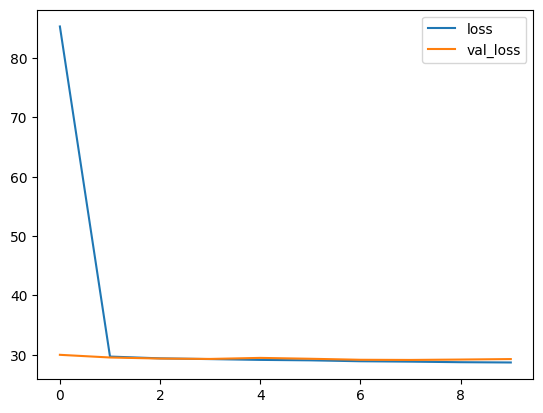

In [22]:
# Graph loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

In [ ]:
# Benchmark against XGBoost
from xgboost import XGBRegressor

# Create model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    random_state=42
    reg_lambda=1.0,
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 20 Most Important Features:")
print(importance.head(20))

MAE: 28.8061
RMSE: 36.0422
R²: 0.3532

Top 20 Most Important Features:
                                        feature  importance
387                          cole_jornada_NOCHE    0.038130
323             cole_cod_dane_sede_320001003571    0.035493
320             cole_cod_dane_sede_320001002753    0.028699
184             cole_cod_dane_sede_120001000115    0.027865
324             cole_cod_dane_sede_320001003661    0.026967
145  cole_cod_dane_establecimiento_320001003571    0.024250
14   cole_cod_dane_establecimiento_120001000115    0.024001
146  cole_cod_dane_establecimiento_320001003661    0.023384
388                       cole_jornada_SABATINA    0.022588
3                             cole_calendario_a    0.022494
4                                  cole_oficial    0.022269
34   cole_cod_dane_establecimiento_120001069246    0.016486
312             cole_cod_dane_sede_320001000378    0.016412
142  cole_cod_dane_establecimiento_320001002753    0.015104
1                            

In [ ]:
# Improved model
model = tf.keras.Sequential([
    input_layer,
    norm_layer,
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1,
)

Epoch 1/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3847.5991 - mae: 40.3961 - val_loss: 1444.3683 - val_mae: 30.1844
Epoch 2/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 1444.5381 - mae: 30.3480 - val_loss: 1428.7900 - val_mae: 30.3321
Epoch 3/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1404.8724 - mae: 29.9380 - val_loss: 1399.2809 - val_mae: 29.9397
Epoch 4/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1388.7538 - mae: 29.7674 - val_loss: 1413.4995 - val_mae: 30.1231
Epoch 5/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1372.0945 - mae: 29.5617 - val_loss: 1411.9823 - val_mae: 30.1356
Epoch 6/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1351.9912 - mae: 29.3403 - val_loss: 1411.8196 - val_mae: 30.2207
Epoch 7/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1349.7242 - mae: 29.3097 - val_loss: 1370.0653 - val_mae: 29.5950
Epoch 8/200
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1333.0505 - mae: 29.1181 - val_los

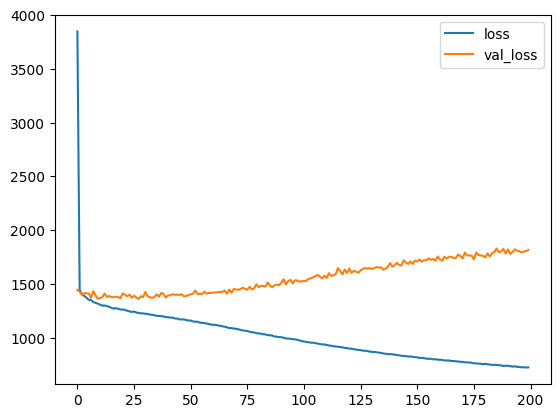

In [24]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

In [26]:
# Benchmark against CatBoost
from catboost import CatBoostRegressor

# Create model
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

# Train model
cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Predictions
y_pred = cat_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Feature importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print("\nTop 20 Most Important Features:")
print(importance.head(20))

0:	learn: 35.9222232	test: 35.6108988	best: 35.6108988 (0)	total: 124ms	remaining: 2m 3s
100:	learn: 31.0627139	test: 30.7186068	best: 30.7186068 (100)	total: 1.12s	remaining: 10s
200:	learn: 30.1459604	test: 29.8203826	best: 29.8203826 (200)	total: 2.24s	remaining: 8.9s
300:	learn: 29.6931899	test: 29.3926352	best: 29.3926352 (300)	total: 3.28s	remaining: 7.62s
400:	learn: 29.3908493	test: 29.1168805	best: 29.1168805 (400)	total: 4.32s	remaining: 6.46s
500:	learn: 29.1527848	test: 28.9177524	best: 28.9177524 (500)	total: 5.32s	remaining: 5.29s
600:	learn: 28.9623610	test: 28.7735836	best: 28.7735836 (600)	total: 6.33s	remaining: 4.2s
700:	learn: 28.8069266	test: 28.6645204	best: 28.6645204 (700)	total: 7.31s	remaining: 3.12s
800:	learn: 28.6737183	test: 28.5805796	best: 28.5805796 (800)	total: 8.24s	remaining: 2.05s
900:	learn: 28.5547719	test: 28.5136052	best: 28.5136052 (900)	total: 9.19s	remaining: 1.01s
999:	learn: 28.4488186	test: 28.4582355	best: 28.4582355 (999)	total: 10.1s	re